## Week 6: Modeling - Feature Engineering & Market Metrics

This section focuses on creating key housing market metrics and analyzing patterns across different regions and property types.

In [1]:
# Load dataset

import pandas as pd
sold = pd.read_csv("../output/sold_cleaned.csv")

print(sold.shape)
sold.head()

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_15846/1981355978.py:4: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../output/sold_cleaned.csv")


(397123, 90)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,missing_coord_flag,zero_coord_flag,invalid_longitude_flag
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,NaN,NaN,NaN,NaN,False,True,False,True,False,False
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


#### Step 2: Select features

In [2]:
features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'DaysOnMarket'
]

X = sold[features]
y = sold['ClosePrice']

#### Step 3: Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Step 4: Train model

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### Step 5: Evaluate

In [6]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 584137.4785202211


In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50)

#### Actual VS Predicted Price

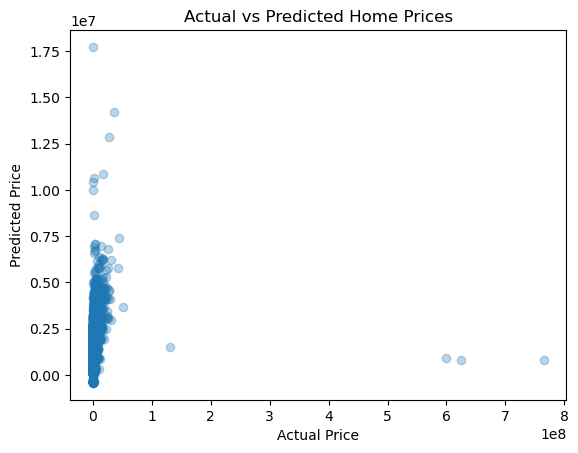

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Home Prices")
plt.show()

#### Error Distribution

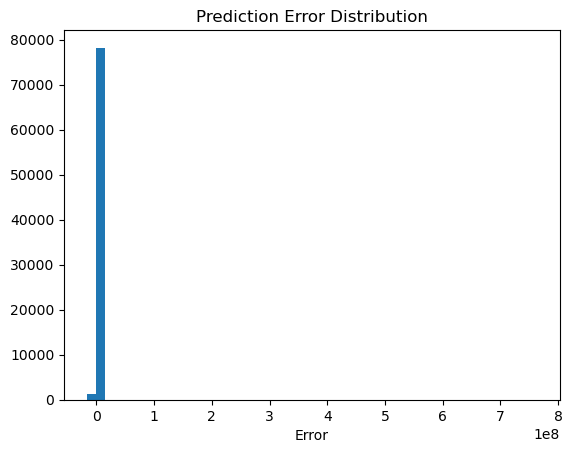

In [9]:
errors = y_test - y_pred

plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

#### Feature Importance

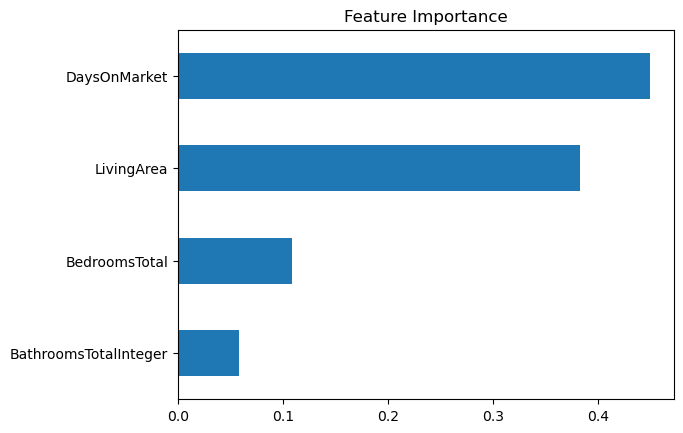

In [10]:
import pandas as pd

importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values()

feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

#### Price vs Living Area

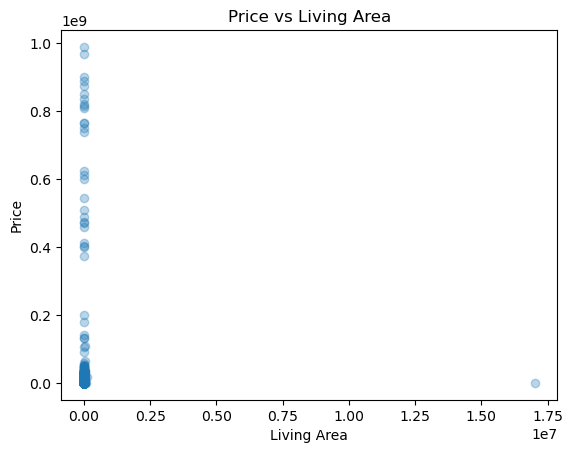

In [11]:
plt.scatter(sold['LivingArea'], sold['ClosePrice'], alpha=0.3)
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Price vs Living Area")
plt.show()

#### Week 6 Summary:

- Created key housing market metrics such as price per square foot, price ratio, and days to close to better represent property value and transaction behavior
- Built time-based features (year, month) to support trend and time-series analysis
- Measured different stages of the transaction process, including listing-to-contract and contract-to-close durations
- Performed segmented analysis by county and property type to uncover differences in pricing and market activity
- Transformed cleaned data into meaningful indicators that reflect negotiation strength, market speed, and regional trends
